## PARTE I – Classificação de Fake News (Fake.Br)


In [ ]:
!pip install gensim transformers torch scikit-learn pandas numpy matplotlib seaborn nltk

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.6/26.6 MB 85.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 117.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.2/38.2 MB 17.5 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.1
    Uninstalling scipy-1.16.1:
      Successfully uninstalled scipy-1.16.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-contrib-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatib

Fake.br


In [ ]:
!pip install gensim transformers torch scikit-learn pandas numpy matplotlib seaborn nltk

In [ ]:

import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB, GaussianNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from gensim.models import Word2Vec
from sklearn.preprocessing import StandardScaler
from transformers import AutoTokenizer, AutoModel
import torch

# Baixar recursos do NLTK
nltk.download('stopwords')
nltk.download('wordnet')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [ ]:

# Função de limpeza de texto

def clean_text(text, stop_words, lemmatizer):
    text = text.lower()
    text = re.sub(r'http\S+|@\w+|#\w+', '', text)
    text = re.sub(r'[^a-záéíóúâêîôûãõç\s]', '', text)
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return " ".join(tokens)


In [ ]:
# Função de avaliação

def evaluate_model(model, X_train, X_test, y_train, y_test, model_name, X_raw_test=None):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"\n{model_name}")
    print("Acurácia:", accuracy_score(y_test, y_pred))
    print("F1-Score (macro):", f1_score(y_test, y_pred, average='macro'))
    print("\nRelatório de Classificação:")
    print(classification_report(y_test, y_pred))
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
    plt.title(f"Matriz de Confusão - {model_name}")
    plt.xlabel("Predito")
    plt.ylabel("Real")
    plt.show()
    if X_raw_test is not None:
        error_mask = y_test != y_pred
        error_texts = pd.DataFrame({
            'text': X_raw_test.values[error_mask],
            'true_label': y_test.values[error_mask],
            'pred_label': y_pred[error_mask]
        })
        file_name = f'ARQ_ERRO_{model_name.replace(" ", "").replace("+", "_")}.csv'
        error_texts.to_csv(file_name, index=False)
        print(f"Erros salvos em: {file_name}")
    return y_test, y_pred

In [ ]:
# Carrega o dataset

import os

csv_path = 'Fakebr.csv'
if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)


stop_words = set(stopwords.words('portuguese'))
lemmatizer = WordNetLemmatizer()
df['clean_text'] = df['preprocessed_news'].astype(str).apply(lambda x: clean_text(x, stop_words, lemmatizer))

# Divisão treino/teste
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    df['clean_text'], df['label'], test_size=0.2 if len(df) >= 5 else 0.5, random_state=42, stratify=df['label'] if df['label'].value_counts().min() > 1 else None)


BoW + NB
Acurácia: 0.8652777777777778
F1-Score (macro): 0.8652268218693796

Relatório de Classificação:
              precision    recall  f1-score   support

        fake       0.88      0.85      0.86       720
        true       0.85      0.88      0.87       720

    accuracy                           0.87      1440
   macro avg       0.87      0.87      0.87      1440
weighted avg       0.87      0.87      0.87      1440



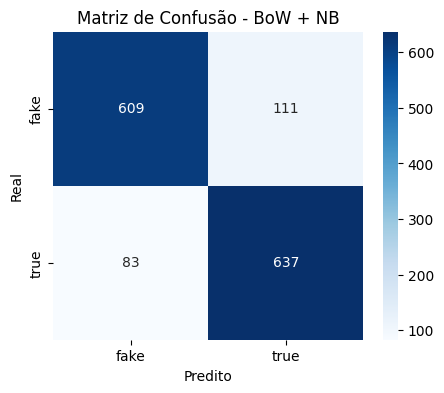

Erros salvos em: ARQ_ERRO_BoW_NB.csv

BoW + SVM
Acurácia: 0.9597222222222223
F1-Score (macro): 0.9597023221343874

Relatório de Classificação:
              precision    recall  f1-score   support

        fake       0.94      0.98      0.96       720
        true       0.98      0.94      0.96       720

    accuracy                           0.96      1440
   macro avg       0.96      0.96      0.96      1440
weighted avg       0.96      0.96      0.96      1440



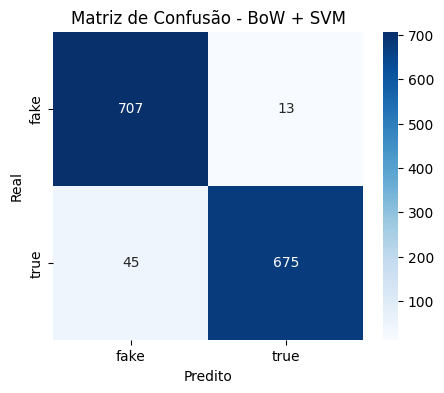

Erros salvos em: ARQ_ERRO_BoW_SVM.csv

TFIDF + NB
Acurácia: 0.8673611111111111
F1-Score (macro): 0.8672914160648604

Relatório de Classificação:
              precision    recall  f1-score   support

        fake       0.89      0.84      0.86       720
        true       0.85      0.89      0.87       720

    accuracy                           0.87      1440
   macro avg       0.87      0.87      0.87      1440
weighted avg       0.87      0.87      0.87      1440



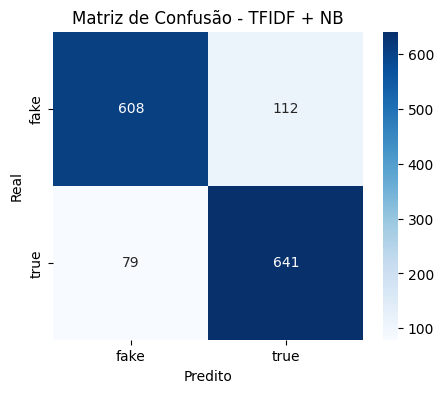

Erros salvos em: ARQ_ERRO_TFIDF_NB.csv

TFIDF + SVM
Acurácia: 0.9680555555555556
F1-Score (macro): 0.9680553090687428

Relatório de Classificação:
              precision    recall  f1-score   support

        fake       0.97      0.97      0.97       720
        true       0.97      0.97      0.97       720

    accuracy                           0.97      1440
   macro avg       0.97      0.97      0.97      1440
weighted avg       0.97      0.97      0.97      1440



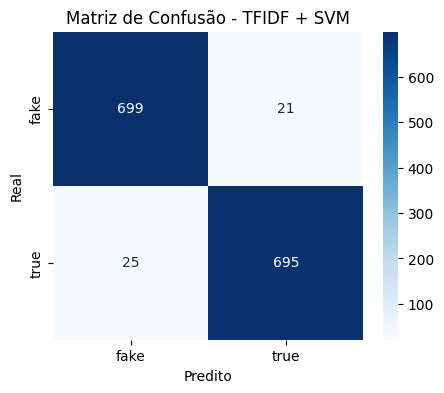

Erros salvos em: ARQ_ERRO_TFIDF_SVM.csv


In [ ]:

# === BoW ===

bow = CountVectorizer(max_features=5000)
X_train_bow = bow.fit_transform(X_train_raw)
X_test_bow = bow.transform(X_test_raw)

y_true_bow_nb, y_pred_bow_nb = evaluate_model(MultinomialNB(), X_train_bow, X_test_bow, y_train, y_test, 'BoW + NB', X_test_raw)
y_true_bow_svm, y_pred_bow_svm = evaluate_model(LinearSVC(max_iter=5000), X_train_bow, X_test_bow, y_train, y_test, 'BoW + SVM', X_test_raw)

# === TF-IDF ===

tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train_raw)
X_test_tfidf = tfidf.transform(X_test_raw)

y_true_tfidf_nb, y_pred_tfidf_nb = evaluate_model(MultinomialNB(), X_train_tfidf, X_test_tfidf, y_train, y_test, 'TFIDF + NB', X_test_raw)
y_true_tfidf_svm, y_pred_tfidf_svm = evaluate_model(LinearSVC(max_iter=5000), X_train_tfidf, X_test_tfidf, y_train, y_test, 'TFIDF + SVM', X_test_raw)



Word2Vec + NB
Acurácia: 0.7465277777777778
F1-Score (macro): 0.7457232301857875

Relatório de Classificação:
              precision    recall  f1-score   support

        fake       0.78      0.69      0.73       720
        true       0.72      0.80      0.76       720

    accuracy                           0.75      1440
   macro avg       0.75      0.75      0.75      1440
weighted avg       0.75      0.75      0.75      1440



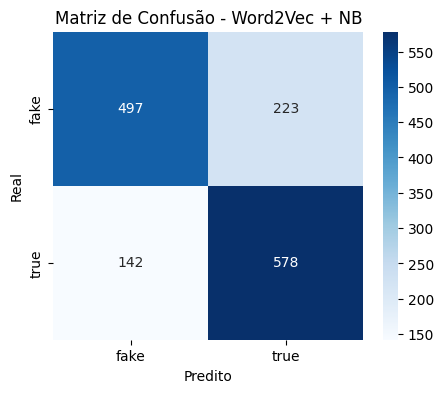

Erros salvos em: ARQ_ERRO_Word2Vec_NB.csv

Word2Vec + SVM
Acurácia: 0.8451388888888889
F1-Score (macro): 0.8446713899230854

Relatório de Classificação:
              precision    recall  f1-score   support

        fake       0.89      0.79      0.84       720
        true       0.81      0.90      0.85       720

    accuracy                           0.85      1440
   macro avg       0.85      0.85      0.84      1440
weighted avg       0.85      0.85      0.84      1440



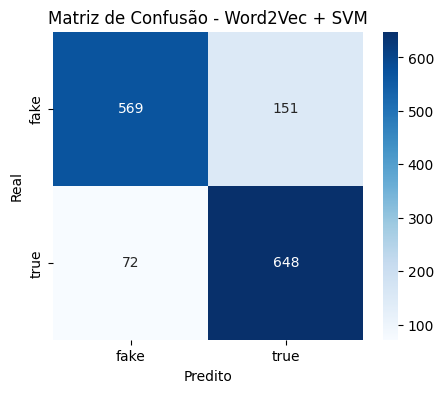

Erros salvos em: ARQ_ERRO_Word2Vec_SVM.csv


In [ ]:

# === Word2Vec ===

tokens = [text.split() for text in X_train_raw]
if tokens:
    w2v_model = Word2Vec(sentences=tokens, vector_size=100, window=5, min_count=2, workers=4, epochs=10)
    def vectorize(text):
        words = text.split()
        vecs = [w2v_model.wv[word] for word in words if word in w2v_model.wv]
        return np.mean(vecs, axis=0) if vecs else np.zeros(w2v_model.vector_size)
    X_train_w2v = np.array([vectorize(text) for text in X_train_raw])
    X_test_w2v = np.array([vectorize(text) for text in X_test_raw])
    scaler = StandardScaler()
    X_train_w2v = scaler.fit_transform(X_train_w2v)
    X_test_w2v = scaler.transform(X_test_w2v)

    y_true_w2v_nb, y_pred_w2v_nb = evaluate_model(GaussianNB(), X_train_w2v, X_test_w2v, y_train, y_test, 'Word2Vec + NB', X_test_raw)
    y_true_w2v_svm, y_pred_w2v_svm = evaluate_model(LinearSVC(max_iter=5000), X_train_w2v, X_test_w2v, y_train, y_test, 'Word2Vec + SVM', X_test_raw)
else:
    print('Sem tokens suficientes para treinar Word2Vec.')


Carregando BERTimbau...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/43.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/647 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Gerando embeddings BERT...


model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]


BERTimbau + NB
Acurácia: 0.7486111111111111
F1-Score (macro): 0.7486033519553073

Relatório de Classificação:
              precision    recall  f1-score   support

        fake       0.75      0.75      0.75       720
        true       0.75      0.74      0.75       720

    accuracy                           0.75      1440
   macro avg       0.75      0.75      0.75      1440
weighted avg       0.75      0.75      0.75      1440



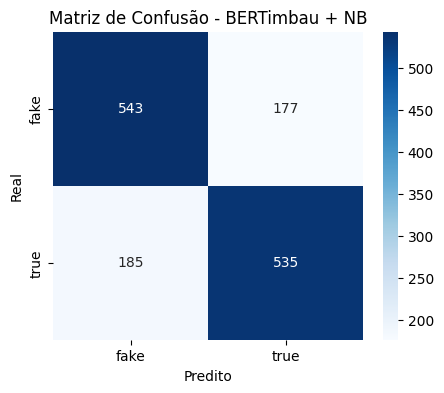

Erros salvos em: ARQ_ERRO_BERTimbau_NB.csv

BERTimbau + SVM
Acurácia: 0.8486111111111111
F1-Score (macro): 0.8485924188171379

Relatório de Classificação:
              precision    recall  f1-score   support

        fake       0.84      0.86      0.85       720
        true       0.86      0.84      0.85       720

    accuracy                           0.85      1440
   macro avg       0.85      0.85      0.85      1440
weighted avg       0.85      0.85      0.85      1440



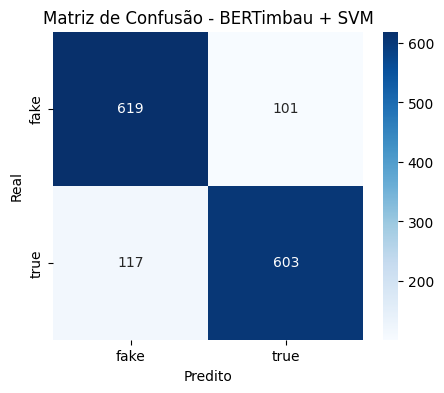

Erros salvos em: ARQ_ERRO_BERTimbau_SVM.csv


In [ ]:

# === BERTimbau ===
print('Carregando BERTimbau...')

# Carrega o tokenizer e o modelo pré-treinado
from transformers import AutoTokenizer, AutoModel
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import LinearSVC
import numpy as np
import torch

try:
    tokenizer = AutoTokenizer.from_pretrained('neuralmind/bert-base-portuguese-cased')
    model = AutoModel.from_pretrained('neuralmind/bert-base-portuguese-cased')
    model.eval()

    def compute_bert_embeddings(texts, max_length=128, batch_size=8):
        embeddings = []
        with torch.no_grad():
            for i in range(0, len(texts), batch_size):
                batch_texts = texts[i:i+batch_size]
                inputs = tokenizer(batch_texts, return_tensors='pt', truncation=True, padding=True, max_length=max_length)
                outputs = model(**inputs)
                cls_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
                embeddings.append(cls_embeddings)
        return np.vstack(embeddings)

    print('Gerando embeddings BERT...')
    X_train_bert = compute_bert_embeddings(list(X_train_raw), max_length=128, batch_size=8)
    X_test_bert = compute_bert_embeddings(list(X_test_raw), max_length=128, batch_size=8)

    # BERTimbau + NB
    y_true_bert_nb, y_pred_bert_nb = evaluate_model(GaussianNB(), X_train_bert, X_test_bert, y_train, y_test, 'BERTimbau + NB', X_test_raw)

    # BERTimbau + SVM
    y_true_bert_svm, y_pred_bert_svm = evaluate_model(LinearSVC(max_iter=5000), X_train_bert, X_test_bert, y_train, y_test, 'BERTimbau + SVM', X_test_raw)
except Exception as e:
    print('Não foi possível carregar o modelo BERTimbau. Certifique-se de que transformers está instalado e você tem acesso à internet.')
    print(e)

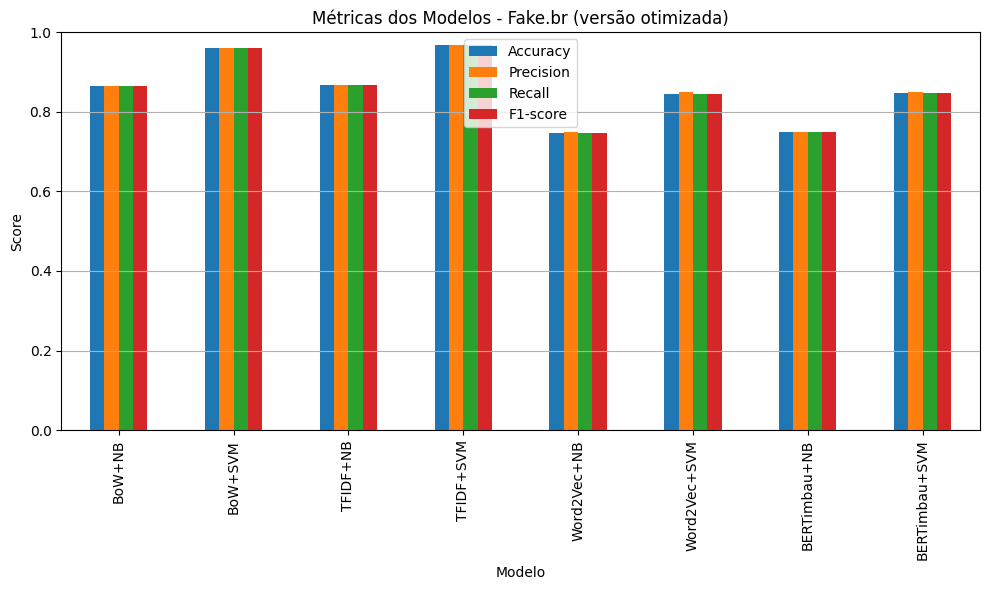

In [ ]:

# === Métricas agregadas ===
resultados = {
    'BoW+NB': (y_true_bow_nb, y_pred_bow_nb),
    'BoW+SVM': (y_true_bow_svm, y_pred_bow_svm),
    'TFIDF+NB': (y_true_tfidf_nb, y_pred_tfidf_nb),
    'TFIDF+SVM': (y_true_tfidf_svm, y_pred_tfidf_svm),
    'Word2Vec+NB': (locals().get('y_true_w2v_nb', []), locals().get('y_pred_w2v_nb', [])),
    'Word2Vec+SVM': (locals().get('y_true_w2v_svm', []), locals().get('y_pred_w2v_svm', [])),
    'BERTimbau+NB': (y_true_bert_nb, y_pred_bert_nb),
    'BERTimbau+SVM': (y_true_bert_svm, y_pred_bert_svm)
}

metricas = []
for modelo, (yt, yp) in resultados.items():
    if len(yt) == 0:
        continue
    relatorio = classification_report(yt, yp, output_dict=True, zero_division=0)
    metricas.append({
        'Modelo': modelo,
        'Accuracy': relatorio['accuracy'],
        'Precision': relatorio['macro avg']['precision'],
        'Recall': relatorio['macro avg']['recall'],
        'F1-score': relatorio['macro avg']['f1-score']
    })

metricas_df = pd.DataFrame(metricas)
metricas_df.to_csv('metricas_fakebr.csv', index=False)

metricas_df.set_index('Modelo')[['Accuracy','Precision','Recall','F1-score']].plot(kind='bar', figsize=(10,6))
plt.title('Métricas dos Modelos - Fake.br (versão otimizada)')
plt.ylabel('Score')
plt.ylim(0.0, 1.0)
plt.grid(axis='y')
plt.tight_layout()
plt.show()


## PARTE II – Classificação de Hate Speech (Hate.Br)

In [ ]:
!pip install gensim transformers torch scikit-learn pandas numpy matplotlib seaborn nltk

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.6/26.6 MB 60.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 81.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.2/38.2 MB 15.4 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.1
    Uninstalling scipy-1.16.1:
      Successfully uninstalled scipy-1.16.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-contrib-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatibl

Fake.br


In [ ]:
!pip install gensim transformers torch scikit-learn pandas numpy matplotlib seaborn nltk

In [ ]:

import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB, GaussianNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from gensim.models import Word2Vec
from sklearn.preprocessing import StandardScaler
from transformers import AutoTokenizer, AutoModel
import torch

# Baixar recursos do NLTK
nltk.download('stopwords')
nltk.download('wordnet')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [ ]:

# Função de limpeza de texto

def clean_text(text, stop_words, lemmatizer):
    text = text.lower()
    text = re.sub(r'http\S+|@\w+|#\w+', '', text)
    text = re.sub(r'[^a-záéíóúâêîôûãõç\s]', '', text)
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return " ".join(tokens)


In [ ]:
# Função de avaliação

def evaluate_model(model, X_train, X_test, y_train, y_test, model_name, X_raw_test=None):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"\n{model_name}")
    print("Acurácia:", accuracy_score(y_test, y_pred))
    print("F1-Score (macro):", f1_score(y_test, y_pred, average='macro'))
    print("\nRelatório de Classificação:")
    print(classification_report(y_test, y_pred))
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
    plt.title(f"Matriz de Confusão - {model_name}")
    plt.xlabel("Predito")
    plt.ylabel("Real")
    plt.show()
    if X_raw_test is not None:
        error_mask = y_test != y_pred
        error_texts = pd.DataFrame({
            'text': X_raw_test.values[error_mask],
            'true_label': y_test.values[error_mask],
            'pred_label': y_pred[error_mask]
        })
        file_name = f'ARQ_ERRO_{model_name.replace(" ", "").replace("+", "_")}.csv'
        error_texts.to_csv(file_name, index=False)
        print(f"Erros salvos em: {file_name}")
    return y_test, y_pred

In [ ]:
# Carrega o dataset

import os

csv_path = 'HateBR.csv'
if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)


stop_words = set(stopwords.words('portuguese'))
lemmatizer = WordNetLemmatizer()
df['clean_text'] = df['comentario'].astype(str).apply(lambda x: clean_text(x, stop_words, lemmatizer))

# Divisão treino/teste
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    df['clean_text'], df['label_final'], test_size=0.2 if len(df) >= 5 else 0.5, random_state=42, stratify=df['label_final'] if df['label_final'].value_counts().min() > 1 else None)


BoW + NB
Acurácia: 0.845
F1-Score (macro): 0.8448916615738238

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.86      0.82      0.84       700
           1       0.83      0.87      0.85       700

    accuracy                           0.84      1400
   macro avg       0.85      0.84      0.84      1400
weighted avg       0.85      0.84      0.84      1400



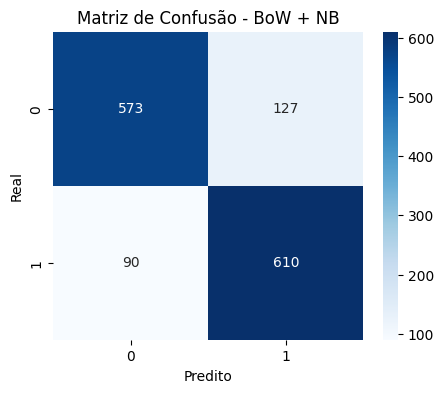

Erros salvos em: ARQ_ERRO_BoW_NB.csv

BoW + SVM
Acurácia: 0.8364285714285714
F1-Score (macro): 0.8360966671796102

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.81      0.88      0.84       700
           1       0.87      0.79      0.83       700

    accuracy                           0.84      1400
   macro avg       0.84      0.84      0.84      1400
weighted avg       0.84      0.84      0.84      1400



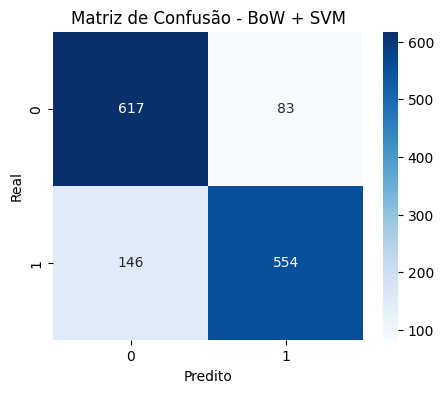

Erros salvos em: ARQ_ERRO_BoW_SVM.csv

TFIDF + NB
Acurácia: 0.8485714285714285
F1-Score (macro): 0.848568647179234

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.85      0.84      0.85       700
           1       0.85      0.85      0.85       700

    accuracy                           0.85      1400
   macro avg       0.85      0.85      0.85      1400
weighted avg       0.85      0.85      0.85      1400



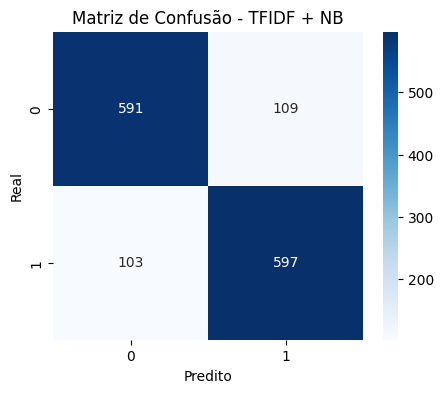

Erros salvos em: ARQ_ERRO_TFIDF_NB.csv

TFIDF + SVM
Acurácia: 0.8321428571428572
F1-Score (macro): 0.8320708018083269

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.82      0.85      0.84       700
           1       0.85      0.81      0.83       700

    accuracy                           0.83      1400
   macro avg       0.83      0.83      0.83      1400
weighted avg       0.83      0.83      0.83      1400



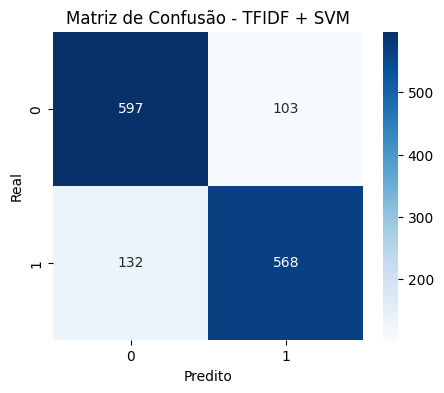

Erros salvos em: ARQ_ERRO_TFIDF_SVM.csv


In [ ]:

# === BoW ===

bow = CountVectorizer(max_features=5000)
X_train_bow = bow.fit_transform(X_train_raw)
X_test_bow = bow.transform(X_test_raw)

y_true_bow_nb, y_pred_bow_nb = evaluate_model(MultinomialNB(), X_train_bow, X_test_bow, y_train, y_test, 'BoW + NB', X_test_raw)
y_true_bow_svm, y_pred_bow_svm = evaluate_model(LinearSVC(max_iter=5000), X_train_bow, X_test_bow, y_train, y_test, 'BoW + SVM', X_test_raw)

# === TF-IDF ===

tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train_raw)
X_test_tfidf = tfidf.transform(X_test_raw)

y_true_tfidf_nb, y_pred_tfidf_nb = evaluate_model(MultinomialNB(), X_train_tfidf, X_test_tfidf, y_train, y_test, 'TFIDF + NB', X_test_raw)
y_true_tfidf_svm, y_pred_tfidf_svm = evaluate_model(LinearSVC(max_iter=5000), X_train_tfidf, X_test_tfidf, y_train, y_test, 'TFIDF + SVM', X_test_raw)



Word2Vec + NB
Acurácia: 0.5257142857142857
F1-Score (macro): 0.519905137882666

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.53      0.42      0.47       700
           1       0.52      0.64      0.57       700

    accuracy                           0.53      1400
   macro avg       0.53      0.53      0.52      1400
weighted avg       0.53      0.53      0.52      1400



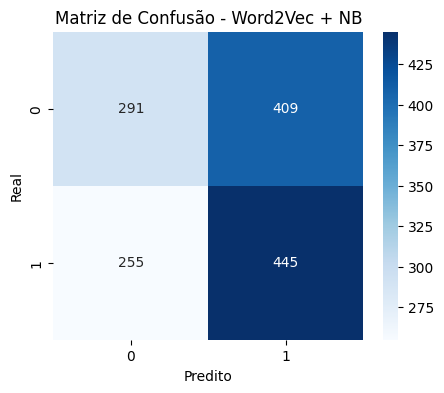

Erros salvos em: ARQ_ERRO_Word2Vec_NB.csv

Word2Vec + SVM
Acurácia: 0.725
F1-Score (macro): 0.7249931248281207

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.72      0.73      0.73       700
           1       0.73      0.72      0.72       700

    accuracy                           0.72      1400
   macro avg       0.73      0.72      0.72      1400
weighted avg       0.73      0.72      0.72      1400



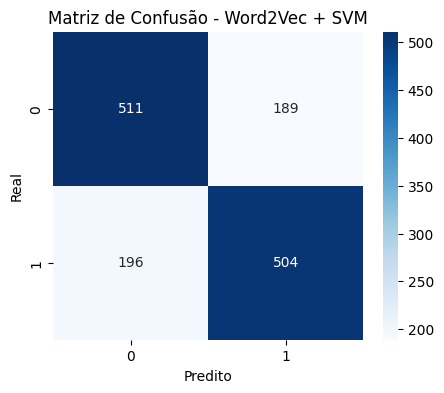

Erros salvos em: ARQ_ERRO_Word2Vec_SVM.csv


In [ ]:

# === Word2Vec ===

tokens = [text.split() for text in X_train_raw]
if tokens:
    w2v_model = Word2Vec(sentences=tokens, vector_size=100, window=5, min_count=2, workers=4, epochs=10)
    def vectorize(text):
        words = text.split()
        vecs = [w2v_model.wv[word] for word in words if word in w2v_model.wv]
        return np.mean(vecs, axis=0) if vecs else np.zeros(w2v_model.vector_size)
    X_train_w2v = np.array([vectorize(text) for text in X_train_raw])
    X_test_w2v = np.array([vectorize(text) for text in X_test_raw])
    scaler = StandardScaler()
    X_train_w2v = scaler.fit_transform(X_train_w2v)
    X_test_w2v = scaler.transform(X_test_w2v)

    y_true_w2v_nb, y_pred_w2v_nb = evaluate_model(GaussianNB(), X_train_w2v, X_test_w2v, y_train, y_test, 'Word2Vec + NB', X_test_raw)
    y_true_w2v_svm, y_pred_w2v_svm = evaluate_model(LinearSVC(max_iter=5000), X_train_w2v, X_test_w2v, y_train, y_test, 'Word2Vec + SVM', X_test_raw)
else:
    print('Sem tokens suficientes para treinar Word2Vec.')


Carregando BERTimbau...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/43.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/647 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Gerando embeddings BERT...


model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]


BERTimbau + NB
Acurácia: 0.8192857142857143
F1-Score (macro): 0.8192856220845011

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.82      0.82      0.82       700
           1       0.82      0.82      0.82       700

    accuracy                           0.82      1400
   macro avg       0.82      0.82      0.82      1400
weighted avg       0.82      0.82      0.82      1400



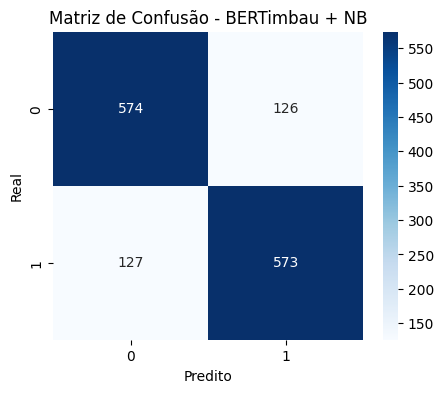

Erros salvos em: ARQ_ERRO_BERTimbau_NB.csv

BERTimbau + SVM
Acurácia: 0.8585714285714285
F1-Score (macro): 0.858571139941102

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.86      0.86      0.86       700
           1       0.86      0.86      0.86       700

    accuracy                           0.86      1400
   macro avg       0.86      0.86      0.86      1400
weighted avg       0.86      0.86      0.86      1400



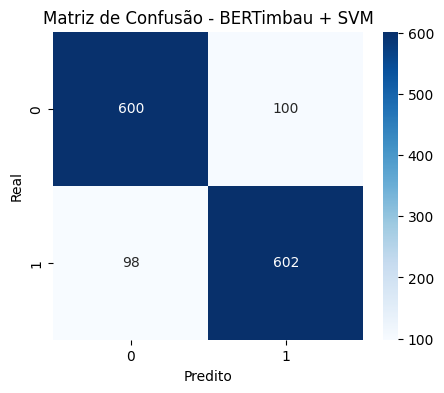

Erros salvos em: ARQ_ERRO_BERTimbau_SVM.csv


In [ ]:

# === BERTimbau ===
print('Carregando BERTimbau...')

# Carrega o tokenizer e o modelo pré-treinado
from transformers import AutoTokenizer, AutoModel
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import LinearSVC
import numpy as np
import torch

try:
    tokenizer = AutoTokenizer.from_pretrained('neuralmind/bert-base-portuguese-cased')
    model = AutoModel.from_pretrained('neuralmind/bert-base-portuguese-cased')
    model.eval()

    def compute_bert_embeddings(texts, max_length=128, batch_size=8):
        embeddings = []
        with torch.no_grad():
            for i in range(0, len(texts), batch_size):
                batch_texts = texts[i:i+batch_size]
                inputs = tokenizer(batch_texts, return_tensors='pt', truncation=True, padding=True, max_length=max_length)
                outputs = model(**inputs)
                cls_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
                embeddings.append(cls_embeddings)
        return np.vstack(embeddings)

    print('Gerando embeddings BERT...')
    X_train_bert = compute_bert_embeddings(list(X_train_raw), max_length=128, batch_size=8)
    X_test_bert = compute_bert_embeddings(list(X_test_raw), max_length=128, batch_size=8)

    # BERTimbau + NB
    y_true_bert_nb, y_pred_bert_nb = evaluate_model(GaussianNB(), X_train_bert, X_test_bert, y_train, y_test, 'BERTimbau + NB', X_test_raw)

    # BERTimbau + SVM
    y_true_bert_svm, y_pred_bert_svm = evaluate_model(LinearSVC(max_iter=5000), X_train_bert, X_test_bert, y_train, y_test, 'BERTimbau + SVM', X_test_raw)
except Exception as e:
    print('Não foi possível carregar o modelo BERTimbau. Certifique-se de que transformers está instalado e você tem acesso à internet.')
    print(e)

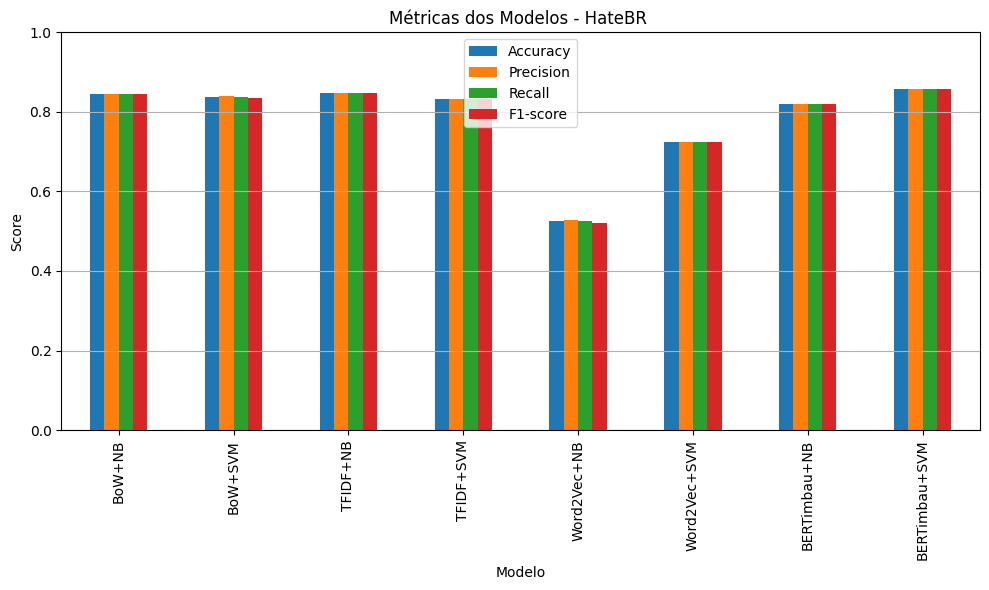

In [ ]:

# === Métricas agregadas ===
resultados = {
    'BoW+NB': (y_true_bow_nb, y_pred_bow_nb),
    'BoW+SVM': (y_true_bow_svm, y_pred_bow_svm),
    'TFIDF+NB': (y_true_tfidf_nb, y_pred_tfidf_nb),
    'TFIDF+SVM': (y_true_tfidf_svm, y_pred_tfidf_svm),
    'Word2Vec+NB': (locals().get('y_true_w2v_nb', []), locals().get('y_pred_w2v_nb', [])),
    'Word2Vec+SVM': (locals().get('y_true_w2v_svm', []), locals().get('y_pred_w2v_svm', [])),
    'BERTimbau+NB': (y_true_bert_nb, y_pred_bert_nb),
    'BERTimbau+SVM': (y_true_bert_svm, y_pred_bert_svm)
}

metricas = []
for modelo, (yt, yp) in resultados.items():
    if len(yt) == 0:
        continue
    relatorio = classification_report(yt, yp, output_dict=True, zero_division=0)
    metricas.append({
        'Modelo': modelo,
        'Accuracy': relatorio['accuracy'],
        'Precision': relatorio['macro avg']['precision'],
        'Recall': relatorio['macro avg']['recall'],
        'F1-score': relatorio['macro avg']['f1-score']
    })

metricas_df = pd.DataFrame(metricas)
metricas_df.to_csv('metricas_HateBR.csv', index=False)

metricas_df.set_index('Modelo')[['Accuracy','Precision','Recall','F1-score']].plot(kind='bar', figsize=(10,6))
plt.title('Métricas dos Modelos - HateBR ')
plt.ylabel('Score')
plt.ylim(0.0, 1.0)
plt.grid(axis='y')
plt.tight_layout()
plt.show()
